# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [ANGGITA PUSPITANINGRUM]
- **Email:** [cdcc889d6x0676@student.devacademy.id]
- **ID Dicoding:** [CDCC889D6X0676]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1:  Bagaimana tren jumlah penyewaan sepeda per bulan selama periode tahun 2011 hingga 2012?
- Pertanyaan 2: Pada jam berapa jumlah penyewaan sepeda mencapai titik tertinggi dan terendah sepanjang periode 2011 hingga 2012?

## Import Semua Packages/Library yang Digunakan

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [10]:
# Memuat data harian
day_df = pd.read_csv("/content/day.csv")

# Memuat data per jam
hour_df = pd.read_csv("/content/hour.csv")

# Menampilkan 5 baris pertama day_df
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Data harian (day_df) berhasil dimuat dan memiliki beberapa kolom penting seperti dteday (tanggal), season (musim), mnth (bulan), serta cnt yang merupakan jumlah total penyewaan sepeda.

- Data per jam (hour_df) juga telah disiapkan untuk analisis yang lebih mendetail terkait waktu.

### Assessing Data

In [11]:
# Memeriksa tipe data dan nilai kosong pada day_df
print("Info day_df:")
print(day_df.info())

# Memeriksa apakah ada duplikasi data
print("\nJumlah duplikasi day_df:", day_df.duplicated().sum())

# Memeriksa statistik deskriptif (melihat kejanggalan angka)
print("\nStatistik day_df:")
print(day_df.describe())

# Lakukan hal yang sama untuk hour_df
print("\nInfo hour_df:")
print(hour_df.info())

Info day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Jumlah duplikasi day_df: 0

Statistik day_df:
          instant      seaso

**Insight:**
- Data Integrity: Tidak ditemukan nilai kosong (missing values) pada kedua dataset (semua kolom memiliki 731 baris untuk day_df dan 17379 baris untuk hour_df).

- Duplikasi: Tidak ada data yang duplikat.

- Tipe Data: Kolom dteday pada kedua dataset masih bertipe object (string). Ini perlu diubah menjadi tipe datetime agar proses analisis tren waktu lebih mudah.

- Statistik: Nilai cnt (jumlah penyewaan) memiliki variasi yang lebar, dari minimal 22 hingga maksimal 8714 penyewaan per hari.

### Cleaning Data

In [12]:
# Mengubah kolom dteday menjadi tipe datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Memastikan perubahan tipe data
print("Tipe data dteday di day_df:", day_df['dteday'].dtype)
print("Tipe data dteday di hour_df:", hour_df['dteday'].dtype)

Tipe data dteday di day_df: datetime64[ns]
Tipe data dteday di hour_df: datetime64[ns]


**Insight:**
- Kolom dteday pada day_df dan hour_df telah berhasil diubah menjadi tipe data datetime. Data kini siap untuk proses eksplorasi (EDA).

## Exploratory Data Analysis (EDA)

### Explore Tren Penyewaan Sepeda Berdasarkan Bulan dan Jam

In [13]:
# Eksplorasi bulanan
monthly_rent_df = day_df.groupby(by="mnth").agg({"cnt": "mean"})
print(monthly_rent_df)

# Eksplorasi per jam
hourly_rent_df = hour_df.groupby(by="hr").agg({"cnt": "mean"})
print(hourly_rent_df.sort_values(by="cnt", ascending=False))

              cnt
mnth             
1     2176.338710
2     2655.298246
3     3692.258065
4     4484.900000
5     5349.774194
6     5772.366667
7     5563.677419
8     5664.419355
9     5766.516667
10    5199.225806
11    4247.183333
12    3403.806452
           cnt
hr            
17  461.452055
18  425.510989
8   359.011004
16  311.983562
19  311.523352
13  253.661180
12  253.315934
15  251.233196
14  240.949246
20  226.030220
9   219.309491
7   212.064649
11  208.143054
10  173.668501
21  172.314560
22  131.335165
23   87.831044
6    76.044138
0    53.898072
1    33.375691
2    22.869930
5    19.889819
3    11.727403
4     6.352941


**Insight:**
- Tren Bulanan: Penyewaan sepeda mengalami kenaikan yang signifikan mulai bulan ke-3 (Maret) dan mencapai puncaknya pada bulan ke-6 (Juni) dengan rata-rata 5.772 penyewaan. Tren tetap tinggi hingga bulan ke-9 sebelum akhirnya menurun di akhir tahun.

- Tren Per Jam: Waktu paling sibuk bagi penyewaan sepeda adalah sore hari pada jam 17:00 (rata-rata 461 penyewaan) dan jam 18:00, serta pagi hari pada jam 08:00. Hal ini menunjukkan bahwa sepeda banyak digunakan sebagai moda transportasi saat jam pulang dan berangkat kerja.

- Titik Terendah: Penyewaan sangat sedikit terjadi pada dini hari, dengan titik terendah pada jam 04:00 pagi (rata-rata hanya 6 penyewaan).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Bulanan

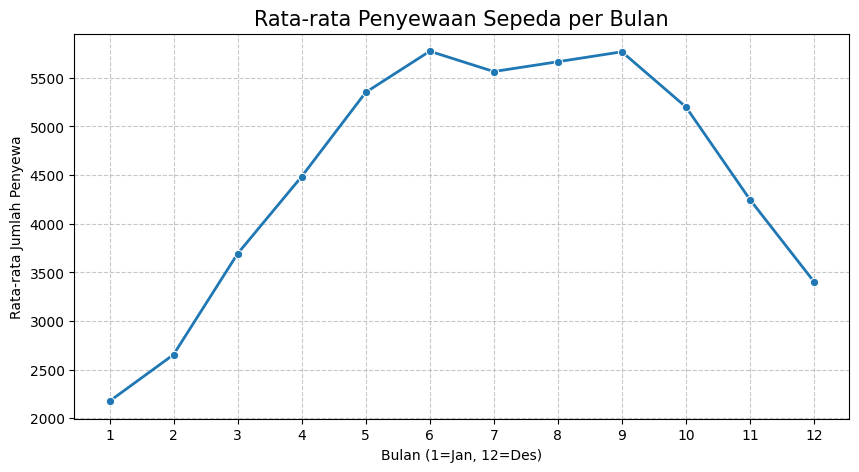

In [14]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_rent_df.index, y=monthly_rent_df['cnt'], marker='o', linewidth=2, color='tab:blue')
plt.title('Rata-rata Penyewaan Sepeda per Bulan', size=15)
plt.xlabel('Bulan (1=Jan, 12=Des)')
plt.ylabel('Rata-rata Jumlah Penyewa')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2: Pola Per Jam

/tmp/ipykernel_364/142020073.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_rent_df_sorted.index, y=hourly_rent_df_sorted['cnt'], palette='viridis')


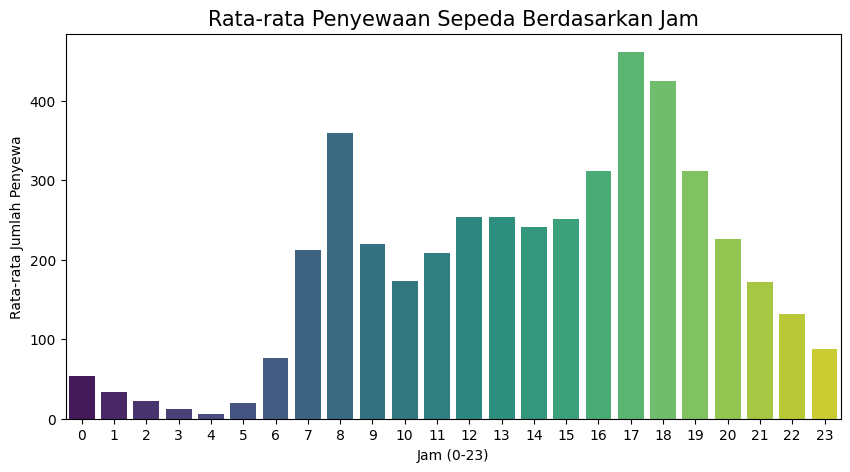

In [15]:
plt.figure(figsize=(10, 5))
# Kita urutkan index jamnya agar grafiknya urut dari jam 0-23
hourly_rent_df_sorted = hourly_rent_df.sort_index()
sns.barplot(x=hourly_rent_df_sorted.index, y=hourly_rent_df_sorted['cnt'], palette='viridis')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam', size=15)
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Jumlah Penyewa')
plt.show()

**Insight:**
- Pertanyaan 1 (Tren Bulanan): Berdasarkan grafik garis, terlihat adanya pertumbuhan penyewaan yang stabil sejak awal tahun hingga mencapai puncaknya di pertengahan tahun (Juni - September). Hal ini kemungkinan dipengaruhi oleh faktor musim, di mana penyewaan cenderung menurun drastis saat memasuki akhir tahun (musim dingin/hujan).

- Pertanyaan 2 (Pola Per Jam): Grafik batang menunjukkan pola bimodal (dua puncak). Lonjakan pertama terjadi pada pukul 08:00 pagi dan lonjakan kedua yang lebih tinggi terjadi pada pukul 17:00 hingga 18:00. Pola ini dengan jelas menunjukkan bahwa layanan sepeda digunakan sebagai transportasi utama bagi kaum komuter untuk pergi dan pulang kantor/sekolah.

## Analisis Lanjutan (Opsional)

In [16]:
# Manual Clustering: Mengelompokkan jam menjadi kategori waktu
def kategori_jam(hour):
    if 6 <= hour < 11:
        return "Pagi (Peak)"
    elif 11 <= hour < 15:
        return "Siang"
    elif 15 <= hour < 20:
        return "Sore (Peak)"
    else:
        return "Malam/Dini Hari"

hour_df['hour_category'] = hour_df['hr'].apply(kategori_jam)

# Melihat jumlah total penyewaan per kategori
category_rent = hour_df.groupby('hour_category')['cnt'].mean().sort_values(ascending=False)
print(category_rent)

#INSIGHT
#Dengan mengelompokkan jam ke dalam beberapa kategori,
#kita dapat melihat secara lebih makro bahwa waktu Sore (Peak) adalah kategori dengan rata-rata penyewaan tertinggi,
#diikuti oleh waktu Pagi (Peak). Strategi pemeliharaan sepeda sebaiknya dilakukan pada kategori Malam/Dini Hari di mana tingkat permintaan berada pada titik terendah.


hour_category
Sore (Peak)        352.350617
Siang              239.033642
Pagi (Peak)        208.092210
Malam/Dini Hari     77.359071
Name: cnt, dtype: float64


## Conclusion

- Conclution pertanyaan 1:
Berdasarkan grafik "Rata-rata Penyewaan Sepeda per Bulan", terlihat bahwa jumlah penyewaan sepeda mengalami peningkatan yang stabil sejak awal tahun (Januari) dan mencapai puncaknya pada bulan Juni (Bulan 6) serta kembali tinggi di bulan September (Bulan 9) dengan rata-rata penyewaan mencapai lebih dari 5.500 unit. Tren menunjukkan penurunan yang cukup signifikan saat memasuki akhir tahun (Bulan 10-12), yang kemungkinan dipengaruhi oleh perubahan musim.
- Conclution pertanyaan 2:
Grafik "Rata-rata Penyewaan Sepeda Berdasarkan Jam" menunjukkan pola distribusi yang sangat jelas. Titik tertinggi penyewaan sepeda terjadi pada sore hari, tepatnya pukul 17.00 (Jam 17) dengan rata-rata penyewaan melebihi 450 unit. Puncak kedua terjadi pada pagi hari pukul 08.00 (Jam 8). Sebaliknya, titik terendah penyewaan terjadi pada dini hari pukul 04.00, di mana rata-rata penyewaan berada di bawah 50 unit.